##  Newton's Divided Difference Interpolation

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
x_data = [0,   1,      2.5,     3,       4.5,     5,       6    ]
y_data = [2.0, 5.4375, 7.35160, 7.56250, 8.44530, 9.18750, 12.0 ]
 
TARGET = 3.5

STEP 1 – Node selection: pick nodes closest to TARGET = 3.5 (same strategy as Lagrange.py for fair comparison)

In [13]:
def get_closest_nodes(x_data, y_data, target, num_nodes):
    """
    Sort all data points by distance from `target`.
    Return the `num_nodes` closest x and y values.
    """
    distances = [(abs(x_data[i] - target), x_data[i], y_data[i])
                 for i in range(len(x_data))]
    distances.sort(key=lambda t: t[0])
 
    x_nodes = [d[1] for d in distances[:num_nodes]]
    y_nodes = [d[2] for d in distances[:num_nodes]]
    return x_nodes, y_nodes

STEP 2 – Build the Divided Difference Table

In [14]:
def build_divided_difference_table(x_nodes, y_nodes):
    """
    Build the full divided difference table.
 
    The table is stored as a 2-D list `dd` where:
        dd[i][0] = f[xi]               (the original y values)
        dd[i][1] = f[xi, xi+1]        (first divided differences)
        dd[i][2] = f[xi, xi+1, xi+2]  (second divided differences)
        ...
 
    We only need the TOP ROW (dd[0][k]) to build the Newton polynomial.
 
    Formula:
        f[xi, ..., xi+k] = (f[xi+1,...,xi+k] - f[xi,...,xi+k-1])
                           / (xi+k - xi)
 
    Parameters
    ----------
    x_nodes : list of x coordinates
    y_nodes : list of y values
 
    Returns
    -------
    dd : 2-D list (n x n)  – the full divided difference table
    """
    n  = len(x_nodes)
 
    # Create an n×n table filled with zeros
    dd = [[0.0] * n for _ in range(n)]
 
    # Fill the first column with the original f(x) values
    for i in range(n):
        dd[i][0] = y_nodes[i]
 
    # Fill the remaining columns column by column
    for col in range(1, n):                  # col = order of difference
        for row in range(n - col):           # rows that can be computed
            numerator   = dd[row + 1][col - 1] - dd[row][col - 1]
            denominator = x_nodes[row + col]  - x_nodes[row]
            dd[row][col] = numerator / denominator
 
    return dd
 

STEP 3 – Print the divided difference table nicely

In [15]:
def print_divided_difference_table(x_nodes, dd):
    n = len(x_nodes)
    col_width = 14
 
    # Header row
    header = f"{'x':>{col_width}}  {'f[x]':>{col_width}}"
    for order in range(1, n):
        header += f"  {'Order-'+str(order):>{col_width}}"
    print(header)
    print("-" * (col_width * (n + 1) + 2 * n))
 
    # Data rows  (lower-triangular – empty cells shown as blank)
    for row in range(n):
        line = f"{x_nodes[row]:>{col_width}.5f}  {dd[row][0]:>{col_width}.8f}"
        for col in range(1, n - row):
            line += f"  {dd[row][col]:>{col_width}.8f}"
        print(line)
 

STEP 4 – Evaluate Newton polynomial of degree k at point x

In [16]:
def newton_evaluate(x_nodes, dd, k, x):
    """
    Evaluate the Newton polynomial of degree k at point x.
 
    Nk(x) = dd[0][0]
           + (x-x0)*dd[0][1]
           + (x-x0)*(x-x1)*dd[0][2]
           + ...
           + (x-x0)*...*(x-x_{k-1}) * dd[0][k]
 
    Parameters
    ----------
    x_nodes : list of x coordinates (already ordered by closeness)
    dd      : divided difference table (2-D list)
    k       : degree of the polynomial  (uses k+1 nodes: 0 .. k)
    x       : evaluation point
 
    Returns
    -------
    result : float
    """
    result = dd[0][0]          # constant term  f[x0]
    product_term = 1.0         # will accumulate  (x-x0)(x-x1)...
 
    for i in range(1, k + 1):
        product_term = product_term * (x - x_nodes[i - 1])
        result       = result + dd[0][i] * product_term
 
    return result
 

STEP 5 – Main: build N2, N3, N4, N5, N6 and show convergence

In [17]:
print("=" * 65)
print("  Newton's Divided Difference  –  Estimating f(3.5)")
print("=" * 65)
 
# We need all 7 nodes for the full table
x_all, y_all = get_closest_nodes(x_data, y_data, TARGET, 7)
 
print(f"\nNode ordering (sorted by distance from {TARGET}):")
for i, (xi, yi) in enumerate(zip(x_all, y_all)):
    dist = abs(xi - TARGET)
    print(f"  Node {i}: x={xi},  y={yi},  dist from {TARGET} = {dist}")
 
# Build the FULL divided difference table once (using all 7 nodes)
dd_full = build_divided_difference_table(x_all, y_all)
 
print("\n--- Full Divided Difference Table ---")
print_divided_difference_table(x_all, dd_full)
 
# Top row of the table = coefficients for the Newton polynomial
print("\nNewton coefficients  dd[0][k]:")
for k in range(7):
    print(f"  dd[0][{k}] = {dd_full[0][k]:.8f}")
 
 
# ---  Evaluate Nk for k = 2, 3, 4, 5, 6  -------------------------
print("\n" + "=" * 65)
print("  Newton Polynomial Evaluation at x = 3.5")
print("=" * 65)
 
previous_value = None
results_table  = []
 
for k in range(2, 7):
    nk_value = newton_evaluate(x_all, dd_full, k, TARGET)
 
    if previous_value is None:
        delta = "   –  "
    else:
        delta = f"{abs(nk_value - previous_value):.8f}"
 
    # Print the Newton form of the polynomial
    print(f"\n--- N{k}(x)  (degree {k}) ---")
    print(f"  Nodes used: {x_all[:k+1]}")
    poly_str = f"  N{k}(x) = {dd_full[0][0]:.6f}"
    term_str = ""
    for i in range(1, k + 1):
        term_str += f"(x - {x_all[i-1]})"
        poly_str += f"\n           + {dd_full[0][i]:.6f} * {term_str}"
    print(poly_str)
    print(f"  N{k}({TARGET}) = {nk_value:.8f}")
    print(f"  Δ{k}          = {delta}")
 
    results_table.append((k, nk_value, delta))
    previous_value = nk_value
 

  Newton's Divided Difference  –  Estimating f(3.5)

Node ordering (sorted by distance from 3.5):
  Node 0: x=3,  y=7.5625,  dist from 3.5 = 0.5
  Node 1: x=2.5,  y=7.3516,  dist from 3.5 = 1.0
  Node 2: x=4.5,  y=8.4453,  dist from 3.5 = 1.0
  Node 3: x=5,  y=9.1875,  dist from 3.5 = 1.5
  Node 4: x=1,  y=5.4375,  dist from 3.5 = 2.5
  Node 5: x=6,  y=12.0,  dist from 3.5 = 2.5
  Node 6: x=0,  y=2.0,  dist from 3.5 = 3.5

--- Full Divided Difference Table ---
             x            f[x]         Order-1         Order-2         Order-3         Order-4         Order-5         Order-6
------------------------------------------------------------------------------------------------------------------------------
       3.00000      7.56250000      0.42180000      0.08336667      0.14582667     -0.00000762      0.00000127      0.00000079
       2.50000      7.35160000      0.54685000      0.37502000      0.14584190     -0.00000381     -0.00000110
       4.50000      8.44530000      1.48440

STEP 6 – Summary convergence table

In [18]:
print("\n" + "=" * 65)
print("  Convergence Summary Table")
print("=" * 65)
print(f"{'Degree k':<12} {'Nk(3.5)':<24} {'Δk = |Nk - Nk-1|'}")
print("-" * 65)
for (k, val, delta) in results_table:
    print(f"  N{k}        {val:<24.8f} {delta}")
print("=" * 65)
 


  Convergence Summary Table
Degree k     Nk(3.5)                  Δk = |Nk - Nk-1|
-----------------------------------------------------------------
  N2        7.81508333                  –  
  N3        7.74217000               0.07291333
  N4        7.74216429               0.00000571
  N5        7.74216667               0.00000238
  N6        7.74216296               0.00000370


STEP 7 – Plot all Newton polynomial curves on one graph

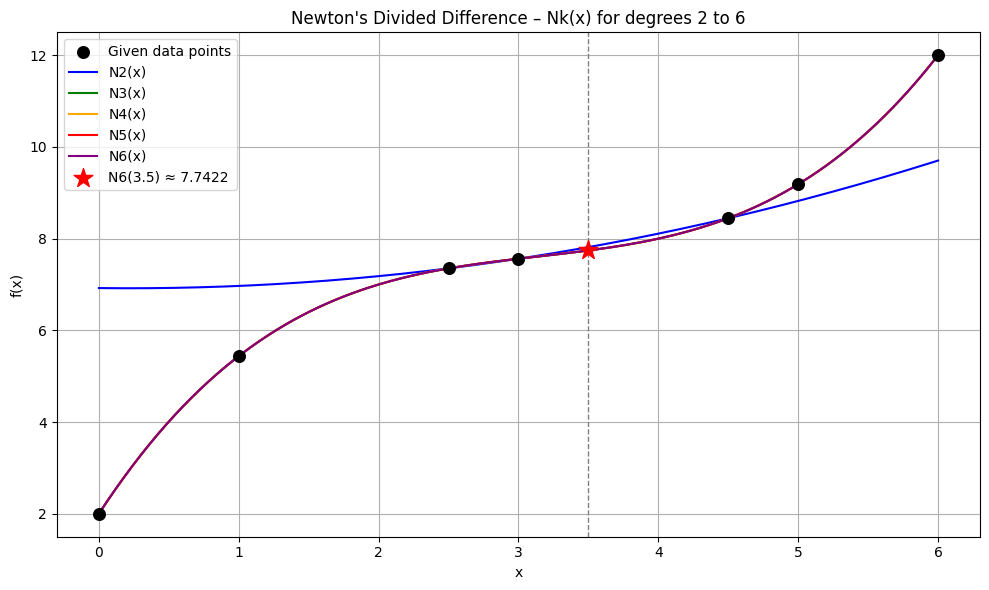


Plot saved as  Newton_plot.png


In [19]:
x_plot = np.linspace(0, 6, 300)
 
plt.figure(figsize=(10, 6))
 
# Original data
plt.scatter(x_data, y_data, color='black', zorder=5,
            label='Given data points', s=70)
 
colors = ['blue', 'green', 'orange', 'red', 'purple']
for idx, (k, val, delta) in enumerate(results_table):
    y_plot = [newton_evaluate(x_all, dd_full, k, xi) for xi in x_plot]
    plt.plot(x_plot, y_plot, color=colors[idx], label=f'N{k}(x)')
 
# Mark target
best_val = results_table[-1][1]
plt.axvline(x=TARGET, color='gray', linestyle='--', linewidth=1)
plt.scatter([TARGET], [best_val], color='red', zorder=6,
            marker='*', s=200, label=f'N6({TARGET}) ≈ {best_val:.4f}')
 
plt.title("Newton's Divided Difference – Nk(x) for degrees 2 to 6")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Newton_plot.png", dpi=150)
plt.show()
print("\nPlot saved as  Newton_plot.png")
 

STEP 8 – Convergence bar chart

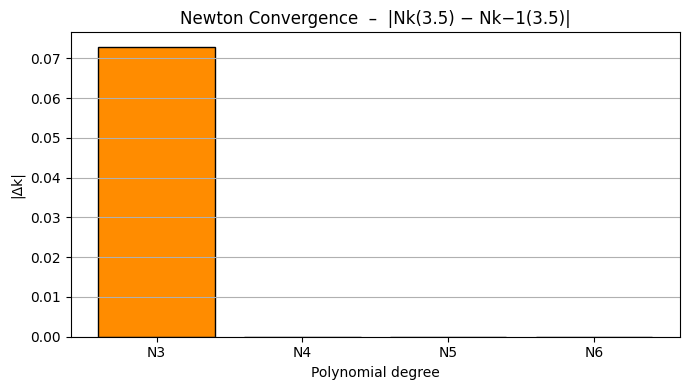

Convergence plot saved as  Newton_convergence.png


In [20]:
degrees = [row[0] for row in results_table[1:]]
deltas  = [float(row[2]) for row in results_table[1:]]
 
plt.figure(figsize=(7, 4))
plt.bar([f"N{k}" for k in degrees], deltas, color='darkorange', edgecolor='black')
plt.title("Newton Convergence  –  |Nk(3.5) − Nk−1(3.5)|")
plt.xlabel("Polynomial degree")
plt.ylabel("|Δk|")
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("Newton_convergence.png", dpi=150)
plt.show()
print("Convergence plot saved as  Newton_convergence.png")
 